## Training Results on Datacomp 1B

I trained tiny models on the first 2 million training samples of DataComp 1B. Looks better.

In [1]:
import pandas as pd
from plotly import express as px
from plotly import subplots

from mole_jepa import model_io, nfs_registry

/home/vpathak/mole_jepa/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ALL_COLS = [
    "train_loss_mse",
    "train_loss_reg_image",
    "train_loss_reg_text",
    "val_loss_mse",
    "val_loss_reg_image",
    "val_loss_reg_text",
]

In [3]:
model_name_map = {
    "vit_small_miniml_jepa_frozen_v2": "MoLeJEPA (Frozen Encoder)",
    "vit_small_miniml_jepa_unfrozen_v2": "MoLeJEPA",
    "vit_small_miniml_infonce_frozen_v2": "VL-JEPA",
}

def get_train_stats(model_name: str) -> pd.DataFrame:
    # TODO: Make this a dict
    cfg = [e for e in nfs_registry.list_entries() if e.name == model_name][0]

    json_path = cfg.checkpoint_dir / "stats.jsonl"

    df = pd.read_json(json_path, lines=True)

    existing_cols = set()
    for col in ALL_COLS:
        if col not in df:
            continue
        if (df[col] == 0).all():
            del df[col]
        else:
            existing_cols.add(col)

    if existing_cols:
        df = df.melt(
            id_vars="epoch",
            value_vars=existing_cols,
            var_name="loss_type",
            value_name="loss",
        )
    else:
        df = df.melt(
            id_vars="epoch",
            value_vars=["train_loss", "val_loss"],
            var_name="loss_type",
            value_name="loss",
        )

    df["train"] = df["loss_type"].str.startswith("train_")
    df["loss_type"] = df["loss_type"].str.replace("train_", "").str.replace("val_", "")
    
    return df

train_stats_per_model = {m: get_train_stats(m) for m in model_name_map}

In [4]:
def plot_stats(stats: pd.DataFrame, train: bool = False):
    if train:
        mask = stats["train"]
    else:
        mask = ~stats["train"]
    stats = stats.loc[mask, :]

    cmap = dict(zip(
        [
            "loss_mse",
            "loss_reg_text",
            "loss_reg_image",
            "loss",
        ],
        px.colors.qualitative.D3,
        
    ))
    
    fig = px.line(
        stats,
        x="epoch",
        y="loss",
        color="loss_type",
        color_discrete_map=cmap
    )

    fig.update_traces(yaxis="y2", selector=dict(name="loss_mse"))

    return fig

all_subplots = [[], []]
all_titles = [[], []]

for model_name, model_display_name in model_name_map.items():
    stats = train_stats_per_model[model_name]
    all_subplots[0].append(plot_stats(stats, train=True))
    all_subplots[1].append(plot_stats(stats, train=False))

    all_titles[0].append(model_display_name + ": Train")
    all_titles[1].append(model_display_name + ": Val")

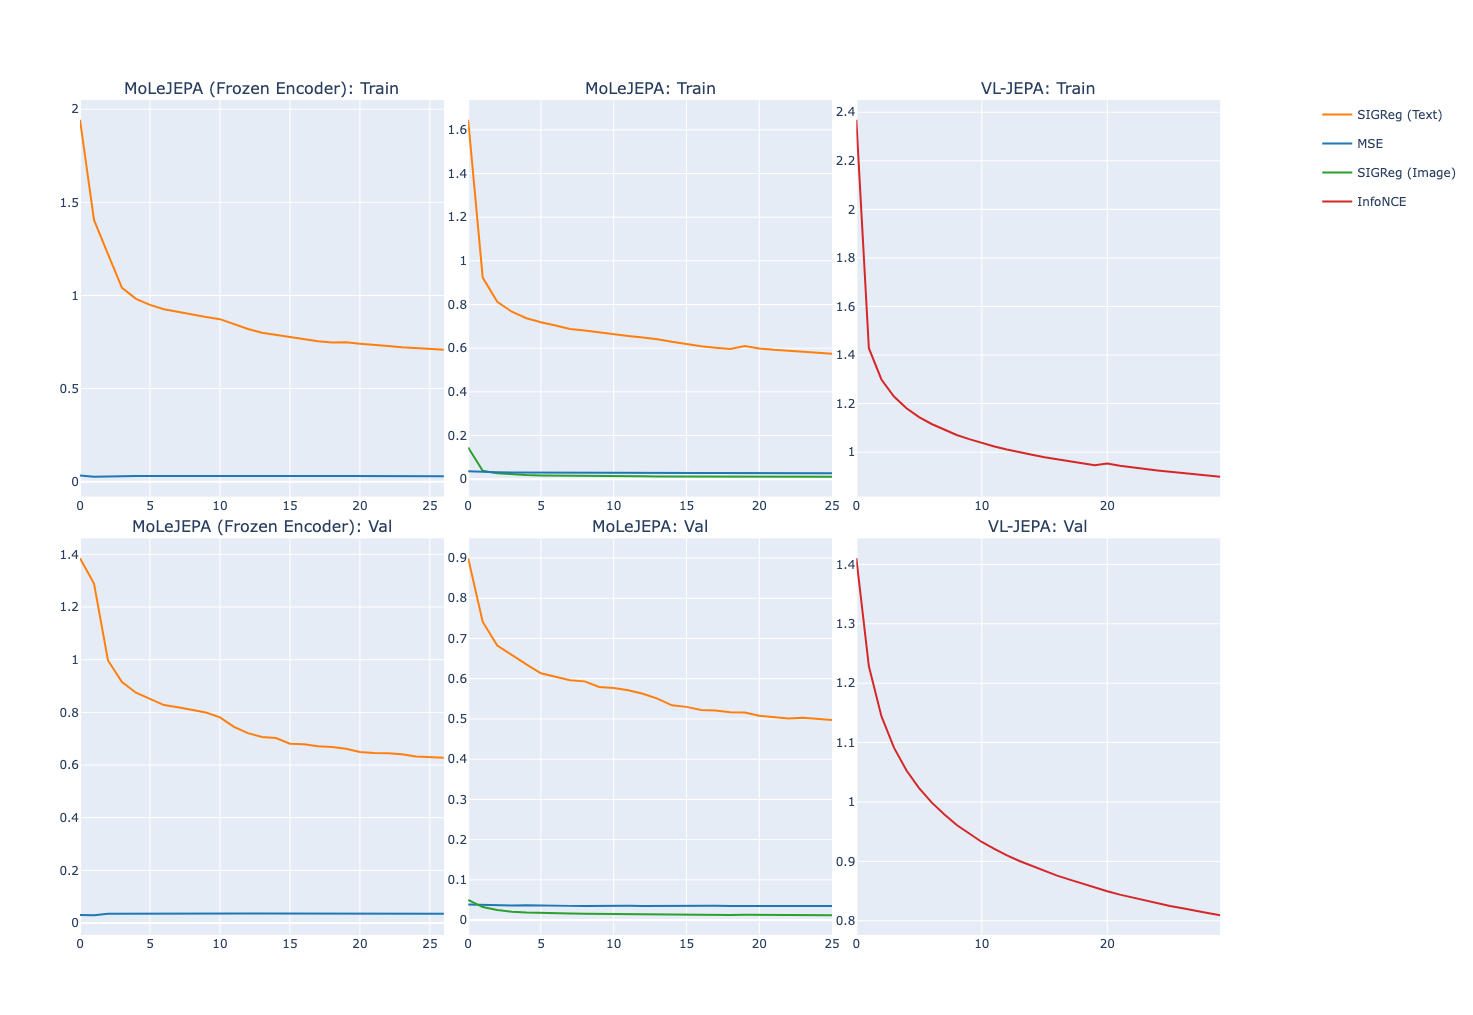

In [5]:
fig = subplots.make_subplots(
    len(all_subplots),
    len(all_subplots[0]),
    subplot_titles=[t for l in all_titles for t in l],
    vertical_spacing=0.05,  # Decrease this for a "tighter" layout
    horizontal_spacing=0.02,
    specs=[[{"secondary_y": True}] * len(all_subplots[0])] * len(all_subplots),
)

for i, plot_l in enumerate(all_subplots):
    for j, plot in enumerate(plot_l):
        for trace in plot.data:
            fig.add_trace(
                trace, row=i + 1, col=j + 1
            )

# Legend name mapping
fig.for_each_trace(
    lambda t: t.update(
        name=t.name.replace("loss_mse", "MSE")
            .replace("loss_reg_text", "SIGReg (Text)")
            .replace("loss_reg_image", "SIGReg (Image)")
            .replace("loss", "InfoNCE")
    ),
)

# Make sure no duplicates in legend
names = set()
fig.for_each_trace(
    lambda trace:
        trace.update(showlegend=False)
        if (trace.name in names) else names.add(trace.name))

fig.update_layout(height=1000, width=2000)
fig.show()